Vectorized Logistic Regression with multiple variables

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

Load the dataset into a pandas dataframe

we observed that the url to load the data is not working so we download the data and load

In [ ]:
df = pd.read_csv('logistic_regression_sample_data.csv')
df.head()

,x1,x2,x3,label
0,-0.332727,-0.696181,-0.286767,0
1,-1.510220,-1.375861,-1.197257,0
2,-1.256076,-1.228764,-1.785996,0
3,-0.772276,-0.409598,-0.267973,0
4,-1.346263,0.112805,0.612268,0


In [ ]:
x1 = np.array(df['x1'], dtype=float)
x2 = np.array(df['x2'], dtype=float)
x3 = np.array(df['x3'], dtype=float)
y = np.array(df['label'], dtype=float)

X = np.column_stack((x1, x2, x3))
display(X.shape, y.shape)
X


(200, 3)

(200,)

array([[-3.32727288e-01, -6.96181041e-01, -2.86766581e-01],
       [-1.51022049e+00, -1.37586113e+00, -1.19725687e+00],
       [-1.25607624e+00, -1.22876370e+00, -1.78599642e+00],
       [-7.72276364e-01, -4.09598435e-01, -2.67973078e-01],
       [-1.34626309e+00,  1.12805059e-01,  6.12267555e-01],
       [ 2.15636892e-01,  2.98918001e-01,  1.03272447e+00],
       [ 6.70567936e-01,  1.92308238e-01,  1.64721375e+00],
       [-1.31646482e-01,  6.91599305e-01,  1.59772213e-02],
       [ 2.38841369e-01,  9.04251521e-01,  2.91584612e-01],
       [-6.28618178e-01, -3.27819886e-01, -3.79269256e-02],
       [ 1.20913644e+00,  7.92472643e-01, -4.47009021e-01],
       [ 9.40205968e-01,  1.49413905e+00,  3.53375636e-01],
       [-1.23353761e+00,  6.66406329e-03,  7.03680945e-01],
       [ 1.34774888e-01, -1.51270519e-01, -5.32092286e-01],
       [-3.77867697e-01,  5.61597099e-01,  1.07528066e-01],
       [ 7.44568943e-01,  2.67232902e-01,  9.54881922e-01],
       [-8.67011677e-01, -6.43080237e-01

Plot the value of X and y

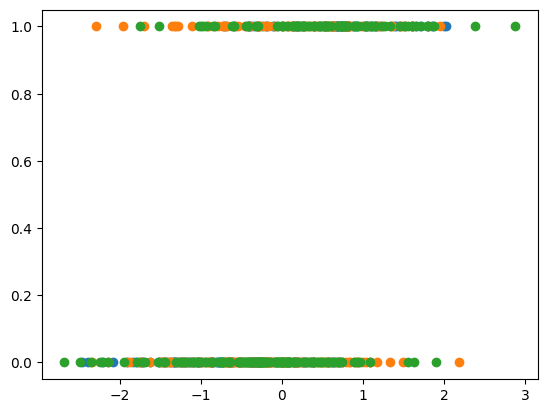

In [ ]:
plt.plot(X, y, 'o')
plt.show()

Vectorized Implementation of Logistic Regression

we first create our Sigmoid function then we create our logistic function

to get our Z, we use the dot function to multiply X and W

after that we calculate our loss

also we generate our gradient adding L2 regularization and updated our parameter. we create an if state to stop the traning if our model have converge

In [ ]:
# Vectorized Implementation of Logistic Regression

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_train_gd(X, y, lr=0.1, epochs=1000, l2=0.0, tol=1e-6, verbose=False):
    """
    X: (N, d) input features (should include bias column if you want bias in weights)
    y: (N,) binary labels 0/1
    """
    N, d = X.shape
    w = np.zeros(d)            # w sometimes theta (𝜃)
    prev_loss = np.inf
    losses = []

    start = time.time()

    for epoch in range(epochs):
        # Prediction
        z = X.dot(w)               # (N,)
        p = sigmoid(z)             # (N,)

        # Loss (average logistic loss)
        eps = 1e-12   # eps (epsilon) is a very low value used to avoid divide-by-zero or log of zero errors.
        loss = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)) + 0.5 * l2 * np.sum(w**2) # the last term is called L2 regularization

        # Gradient
        grad = (X.T.dot(p - y)) / N + l2 * w  # Shape is (d,N). Last term is L2 regularization.

        # Parameter update
        w -= lr * grad

        # Stopping condition: stop if difference btw current loss and prev loss is less than 'tol'.
        if abs(prev_loss - loss) < tol:
            if verbose:
                print(f"Converged at epoch {epoch}, loss={loss:.6f}")
            break
        prev_loss = loss
        losses.append(loss)

        if verbose and (epoch % 100 == 0):
            print(f"Epoch {epoch:4d}, loss={loss:.6f}")

    end = time.time()
    print(f"Time taken: {end - start} seconds")

    return w, losses


here we add a column of 1's at the beginning of X to act as the bias term

In [ ]:
# Add a column of 1's at the beginning of X to act as the bias term
X_train = np.hstack([np.ones((len(x1),1)), X])
y_train = y
X_train

array([[ 1.00000000e+00, -3.32727288e-01, -6.96181041e-01,
        -2.86766581e-01],
       [ 1.00000000e+00, -1.51022049e+00, -1.37586113e+00,
        -1.19725687e+00],
       [ 1.00000000e+00, -1.25607624e+00, -1.22876370e+00,
        -1.78599642e+00],
       [ 1.00000000e+00, -7.72276364e-01, -4.09598435e-01,
        -2.67973078e-01],
       [ 1.00000000e+00, -1.34626309e+00,  1.12805059e-01,
         6.12267555e-01],
       [ 1.00000000e+00,  2.15636892e-01,  2.98918001e-01,
         1.03272447e+00],
       [ 1.00000000e+00,  6.70567936e-01,  1.92308238e-01,
         1.64721375e+00],
       [ 1.00000000e+00, -1.31646482e-01,  6.91599305e-01,
         1.59772213e-02],
       [ 1.00000000e+00,  2.38841369e-01,  9.04251521e-01,
         2.91584612e-01],
       [ 1.00000000e+00, -6.28618178e-01, -3.27819886e-01,
        -3.79269256e-02],
       [ 1.00000000e+00,  1.20913644e+00,  7.92472643e-01,
        -4.47009021e-01],
       [ 1.00000000e+00,  9.40205968e-01,  1.49413905e+00,
      

Train using the above logistic function.


In [ ]:
# Train using the above logistic function.
w, losses = logistic_train_gd(X_train, y_train, lr=0.1, epochs=1_000_000, l2=1e-4, verbose=True)

Epoch    0, loss=0.693147
Epoch  100, loss=0.404987
Epoch  200, loss=0.336550
Epoch  300, loss=0.294731
Epoch  400, loss=0.266234
Epoch  500, loss=0.245430
Epoch  600, loss=0.229469
Epoch  700, loss=0.216762
Epoch  800, loss=0.206353
Epoch  900, loss=0.197633
Epoch 1000, loss=0.190193
Epoch 1100, loss=0.183751
Epoch 1200, loss=0.178103
Epoch 1300, loss=0.173098
Epoch 1400, loss=0.168624
Epoch 1500, loss=0.164593
Epoch 1600, loss=0.160937
Epoch 1700, loss=0.157600
Epoch 1800, loss=0.154539
Epoch 1900, loss=0.151718
Epoch 2000, loss=0.149107
Epoch 2100, loss=0.146681
Epoch 2200, loss=0.144420
Epoch 2300, loss=0.142305
Epoch 2400, loss=0.140322
Epoch 2500, loss=0.138457
Epoch 2600, loss=0.136700
Epoch 2700, loss=0.135040
Epoch 2800, loss=0.133468
Epoch 2900, loss=0.131978
Epoch 3000, loss=0.130563
Epoch 3100, loss=0.129216
Epoch 3200, loss=0.127932
Epoch 3300, loss=0.126707
Epoch 3400, loss=0.125537
Epoch 3500, loss=0.124416
Epoch 3600, loss=0.123343
Epoch 3700, loss=0.122314
Epoch 3800, 

after training, we Visualize our output

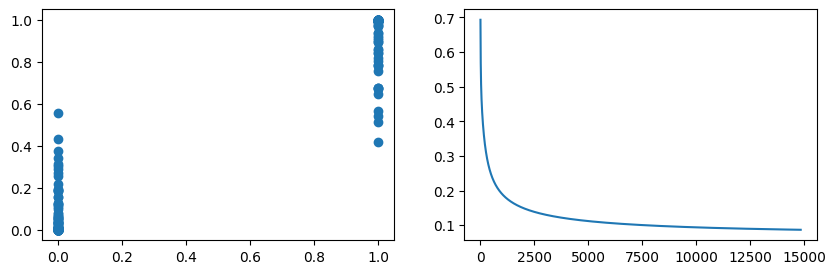

In [ ]:
y_pred = sigmoid(X_train.dot(w))
plt.figure(figsize=(10, 3))
plt.subplot(1,2,1)
plt.plot(y_train, y_pred, 'o')

plt.subplot(1,2,2)
plt.plot(losses)